# Chapter 6 — Frequentist and Bayesian Uncertainty

This notebook accompanies **Chapter 6** of *Inference in Statistical Modelling and Machine Learning*.

## Key ideas

We have a model with an unknown parameter and some data. There are two traditions for quantifying our **uncertainty** about the parameter:

- **Frequentist**: the parameter is a fixed unknown constant. Uncertainty is expressed through the *sampling distribution* — the spread of estimates we would see if the data-collection process were repeated many times. Key tools: standard error, confidence interval.
- **Bayesian**: the parameter is treated as a random variable. We describe our beliefs using a *prior* distribution, then update it with data via Bayes' rule to get a *posterior* distribution. Key tools: credible interval, posterior mean.

The chapter works through both approaches using a single, clean example: estimating the sex ratio of a wild lizard population from a sequence of observed births.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist   # the Beta distribution
from scipy.stats import norm                # the normal distribution

---
## The data

Researchers in Tasmania recorded the sex of each newborn from a population of viviparous lizards (*Niveoscincus ocellatus*) over many years.  Each row is one lizard birth: `Male = 1` for a male, `Male = 0` for a female.

> **Book link — §6.3 Lizard sex ratios.**  The chapter models the sex of the $i$th newborn as a Bernoulli random variable $X_i$ with unknown probability $p$ of being male.  Our goal is to estimate $p$ from the observed sequence.

In [2]:
data = pd.read_csv('../DATA/CP_birth_sequence.csv')
x    = data['Male'].values     # 0/1 array, one entry per birth

print(f"Total births recorded: {len(x)}")
print(f"Males: {x.sum()}   Females: {(1-x).sum()}")
print(f"Overall fraction male: {x.mean():.4f}")
print()
print("First ten births:", x[:10])

Total births recorded: 4255
Males: 2226   Females: 2029
Overall fraction male: 0.5231

First ten births: [1 1 0 1 0 0 1 1 0 0]


---
## The running maximum-likelihood estimate

After observing $n$ births, the maximum-likelihood estimate (MLE) of $p$ is simply the fraction of males seen so far:

$$\hat{p}_n = \frac{s_n}{n}, \qquad \text{where } s_n = x_1 + x_2 + \cdots + x_n.$$

Let's watch this estimate evolve birth by birth.  We'll also add the 95% **confidence interval**, whose half-width is $1.96 \times \hat{\text{se}}$ where the plug-in standard error is $\hat{\text{se}} = \sqrt{\hat{p}(1-\hat{p})/n}$.

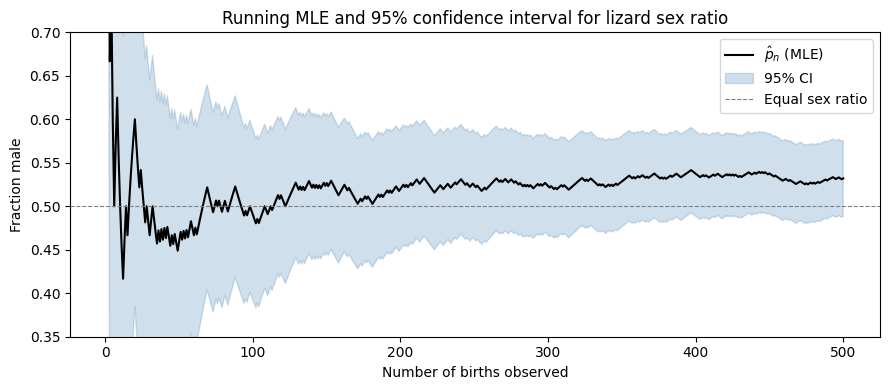

After 500 births:  p̂ = 0.532,  ŝe = 0.022
95% CI: [0.488,  0.576]


In [3]:
n_max = 500               # use the first 500 births to match the book's Figure 6.1
x500  = x[:n_max]

ns    = np.arange(1, n_max + 1)
s_n   = np.cumsum(x500)           # running count of males
p_hat = s_n / ns                  # running MLE

se_hat = np.sqrt(p_hat * (1 - p_hat) / ns)   # plug-in standard error

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ns, p_hat, 'k', linewidth=1.5, label=r'$\hat{p}_n$ (MLE)')
ax.fill_between(ns,
                p_hat - 1.96 * se_hat,
                p_hat + 1.96 * se_hat,
                alpha=0.25, color='steelblue', label='95% CI')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Equal sex ratio')
ax.set_xlabel('Number of births observed')
ax.set_ylabel('Fraction male')
ax.set_title('Running MLE and 95% confidence interval for lizard sex ratio')
ax.legend()
ax.set_ylim(0.35, 0.70)
plt.tight_layout()
plt.show()

p500   = p_hat[-1]
se500  = se_hat[-1]
print(f"After {n_max} births:  p̂ = {p500:.3f},  ŝe = {se500:.3f}")
print(f"95% CI: [{p500 - 1.96*se500:.3f},  {p500 + 1.96*se500:.3f}]")

Early on the estimate is erratic — a run of males makes $\hat{p}$ shoot up, a run of females pulls it down.  As $n$ grows the CI shrinks and the estimate settles.  This is the frequentist picture of uncertainty: we are confident the interval-constructing procedure traps the true $p$ 95% of the time over repeated experiments.

---
## Bayesian updating: the Beta posterior

Now the Bayesian view.  We treat $p$ as a random variable and start with a **uniform prior** $f_P(p) = 1$ for $p \in [0, 1]$ (equal belief in every possible value).  After observing $s_n$ males in $n$ births, Bayes' rule gives a **posterior** that is a Beta distribution (§6.5, eq. 6.7):

$$P \mid x_1,\ldots,x_n \;\sim\; \mathrm{Beta}(s_n + 1,\; n - s_n + 1).$$

As more data arrive, the posterior concentrates around the true sex ratio.

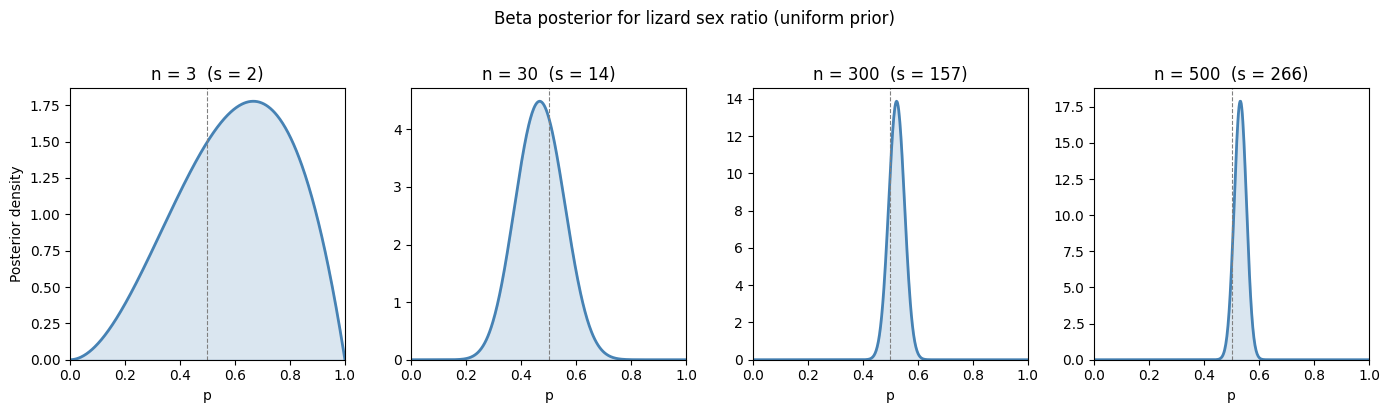

In [4]:
p_grid       = np.linspace(0, 1, 500)
checkpoints  = [3, 30, 300, 500]

fig, axes = plt.subplots(1, len(checkpoints), figsize=(14, 4), sharey=False)

for ax, n in zip(axes, checkpoints):
    s  = x[:n].sum()                          # males seen so far
    alpha_post = s + 1
    beta_post  = n - s + 1
    pdf = beta_dist.pdf(p_grid, alpha_post, beta_post)

    ax.plot(p_grid, pdf, 'steelblue', linewidth=2)
    ax.fill_between(p_grid, pdf, alpha=0.2, color='steelblue')
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title(f'n = {n}  (s = {s})')
    ax.set_xlabel('p')
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('Posterior density')
plt.suptitle('Beta posterior for lizard sex ratio (uniform prior)', y=1.02)
plt.tight_layout()
plt.show()

Each panel is our complete state of knowledge about $p$ after seeing that many births.  The posterior is wide when data is scarce and narrows as evidence accumulates.  The **posterior mean** is $(s_n + 1)/(n + 2)$ — very close to the MLE for large $n$.

> **Book link — §6.5.4 Bayesian credible intervals.**  Unlike a confidence interval, a 95% *credible interval* $[a, b]$ means we genuinely believe (according to our posterior) that $p \in [a, b]$ with probability 0.95.  We find $a$ and $b$ as the 2.5th and 97.5th percentiles of the Beta posterior.

After n = 500 births  (s = 266 males)
  MLE p̂ = 0.5320
  Frequentist 95% CI:       [0.4883,  0.5757]
  Bayesian 95% credible:    [0.4882,  0.5753]


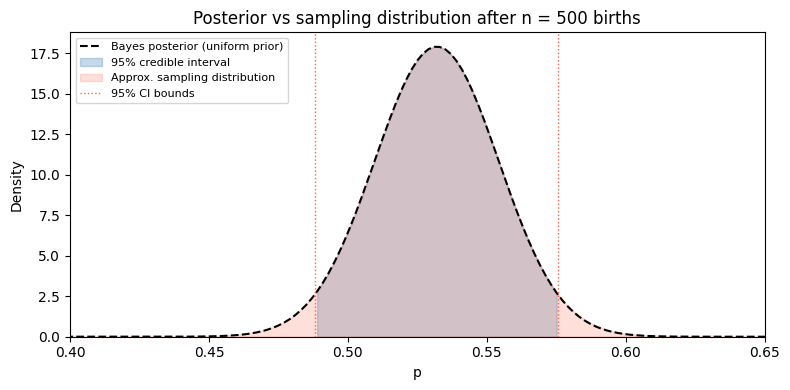

In [5]:
# Compare the frequentist 95% CI with the Bayesian 95% credible interval after 500 births
n_use = 500
s_use = x[:n_use].sum()
p_mle = s_use / n_use
se    = np.sqrt(p_mle * (1 - p_mle) / n_use)

ci_lo, ci_hi = p_mle - 1.96 * se, p_mle + 1.96 * se
cr_lo, cr_hi = beta_dist.ppf(0.025, s_use + 1, n_use - s_use + 1), \
               beta_dist.ppf(0.975, s_use + 1, n_use - s_use + 1)

print(f"After n = {n_use} births  (s = {s_use} males)")
print(f"  MLE p̂ = {p_mle:.4f}")
print(f"  Frequentist 95% CI:       [{ci_lo:.4f},  {ci_hi:.4f}]")
print(f"  Bayesian 95% credible:    [{cr_lo:.4f},  {cr_hi:.4f}]")

# Overlay both on the posterior
alpha_post = s_use + 1
beta_post  = n_use - s_use + 1
pdf        = beta_dist.pdf(p_grid, alpha_post, beta_post)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p_grid, pdf, 'k--', linewidth=1.5, label='Bayes posterior (uniform prior)')
ax.fill_between(p_grid, pdf,
                where=(p_grid >= cr_lo) & (p_grid <= cr_hi),
                alpha=0.3, color='steelblue', label='95% credible interval')
ax.fill_between(p_grid,
                norm.pdf(p_grid, p_mle, se), alpha=0.2, color='tomato',
                label='Approx. sampling distribution')
ax.axvline(ci_lo, color='tomato', linestyle=':', linewidth=1)
ax.axvline(ci_hi, color='tomato', linestyle=':', linewidth=1, label='95% CI bounds')
ax.set_xlabel('p')
ax.set_ylabel('Density')
ax.set_title(f'Posterior vs sampling distribution after n = {n_use} births')
ax.legend(fontsize=8)
ax.set_xlim(0.40, 0.65)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

The two distributions are nearly identical — the chapter explains why this happens in §6.8.  With enough data, the frequentist and Bayesian answers converge.

---
## Exercises

### Exercise 1 — Hypothesis test

Fisher's principle predicts an equal sex ratio: $H_0: p = \frac{1}{2}$.  Use the first 500 births to test this at the 5% significance level.  Compute the Z-statistic and the p-value.

The Z-statistic is $Z = |\hat{p} - p_0| / \hat{\text{se}}$.  Reject $H_0$ if $Z > z_{0.025} = 1.96$.

In [7]:
# Your answer here
p0   = 0.5
# z    = ...
# pval = ...

In [8]:
# Solution
n_test = 500
s_test = x[:n_test].sum()
p_hat_test = s_test / n_test
se_test    = np.sqrt(p_hat_test * (1 - p_hat_test) / n_test)

z    = abs(p_hat_test - p0) / se_test
pval = 2 * norm.cdf(-z)          # two-sided p-value

print(f"p̂ = {p_hat_test:.3f},  ŝe = {se_test:.3f}")
print(f"Z-statistic = {z:.3f}")
print(f"p-value = {pval:.3f}")
print()
if z > 1.96:
    print("Reject H₀ at the 5% level.")
else:
    print("Cannot reject H₀ at the 5% level — consistent with equal sex ratio.")

# The book gets Z = 1.41 and p-value = 0.159 (same conclusion).

p̂ = 0.532,  ŝe = 0.022
Z-statistic = 1.434
p-value = 0.152

Cannot reject H₀ at the 5% level — consistent with equal sex ratio.


### Exercise 2 — An informative prior

The uniform prior expresses complete ignorance about $p$.  Suppose instead you are a biologist who strongly believes Fisher's principle and encodes this as a $\mathrm{Beta}(20, 20)$ prior — sharply peaked around $p = 0.5$.

Plot this prior alongside the posterior you get after 3, 30, and 500 observations.  How quickly does the data override the strong prior belief?  Compare with the uniform-prior posteriors above.

In [8]:
# Your answer — hint: with a Beta(a0, b0) prior and s males in n observations,
# the posterior is Beta(a0 + s, b0 + n - s)

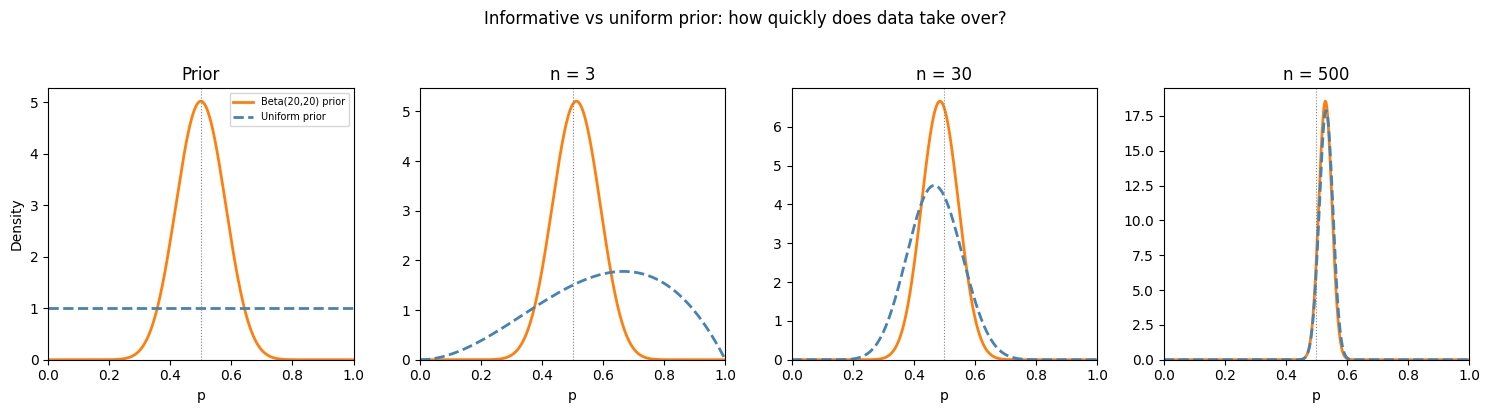

In [9]:
# Solution
a0, b0 = 20, 20          # informative prior: strongly believes p ≈ 0.5

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=False)
checkpoints2 = [0, 3, 30, 500]

for ax, n in zip(axes, checkpoints2):
    s = int(x[:n].sum()) if n > 0 else 0
    pdf_informative = beta_dist.pdf(p_grid, a0 + s,  b0 + n - s)
    pdf_uniform     = beta_dist.pdf(p_grid, 1  + s,  1  + n - s)
    ax.plot(p_grid, pdf_informative, 'C1', linewidth=2,   label='Beta(20,20) prior')
    ax.plot(p_grid, pdf_uniform,     'steelblue', linewidth=2, linestyle='--', label='Uniform prior')
    ax.axvline(0.5, color='grey', linestyle=':', linewidth=0.8)
    label = 'Prior' if n == 0 else f'n = {n}'
    ax.set_title(label)
    ax.set_xlabel('p')
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('Density')
axes[0].legend(fontsize=7)
plt.suptitle('Informative vs uniform prior: how quickly does data take over?', y=1.02)
plt.tight_layout()
plt.show()

# With n=3 the informative prior dominates; by n=30 the two posteriors are already similar;
# by n=500 they are almost identical — the data overwhelms the prior.